# Warehouse Layer — Interactive SQL Analysis
### Early Disease Prediction Using Healthcare Data Warehouse

**Purpose:** This notebook runs all 20 analytical SQL queries from
`warehouse/analytical_queries.sql` directly against the SQLite data
warehouse and renders each result as a formatted pandas DataFrame.

| Section | Queries | OLAP Operation |
|---|---|---|
| 1 — Data Quality Verification | Q-01 to Q-04 | Audit / Validation |
| 2 — Dimension Table Analysis | Q-05 to Q-07 | Descriptive / Roll-Up |
| 3 — Disease Prevalence | Q-08 to Q-10 | Roll-Up / Slice |
| 4 — Disease-Specific Deep Dives | Q-11 to Q-14 | Drill-Down |
| 5 — Cross-Disease JOIN Analysis | Q-15 to Q-17 | Join / Dice |
| 6 — Advanced OLAP Operations | Q-18 to Q-20 | Roll-Up / Slice / Dice |

**Database:** `warehouse/health_warehouse.db`
**Tables:** `dim_patient` · `fact_autism` · `fact_diabetes` · `fact_stroke`
**Views:**  `vw_autism_full` · `vw_diabetes_full` · `vw_stroke_full` · `vw_disease_summary`

In [1]:
import os
import sqlite3
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns',  50)
pd.set_option('display.max_rows',     60)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width',       120)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'      : 110,
    'figure.facecolor': 'white',
    'axes.titleweight': 'bold',
    'axes.titlesize'  : 12,
})

# --- Path resolution (works from project root or warehouse/) ---
_cwd  = Path.cwd()
ROOT  = _cwd.parent if _cwd.name == 'warehouse' else _cwd
DB    = ROOT / 'warehouse' / 'health_warehouse.db'
FIGS  = ROOT / 'reports'  / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

assert DB.exists(), f"Database not found: {DB}. Run etl_pipeline/warehouse.py first."

conn = sqlite3.connect(DB)
conn.execute("PRAGMA foreign_keys = ON")
conn.execute("PRAGMA journal_mode  = WAL")

def sql(query: str, title: str = "") -> pd.DataFrame:
    df = pd.read_sql_query(query, conn)
    if title:
        print(f"  {title}  ({len(df):,} rows x {len(df.columns)} cols)")
    return df

def savefig(fname: str) -> None:
    plt.savefig(FIGS / fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"  [SAVED] reports/figures/{fname}")

print(f"Connected to : {DB}")
print(f"DB size      : {DB.stat().st_size / 1024:.1f} KB")
print()

# Confirm all objects exist
objects = sql("SELECT type, name FROM sqlite_master "
              "WHERE type IN ('table','view','index') "
              "AND name NOT LIKE 'sqlite_%' "
              "ORDER BY type, name")
print("Warehouse objects:")
for _, row in objects.iterrows():
    print(f"  [{row['type'].upper():<6}]  {row['name']}")

Connected to : D:\NMU\Data Mining\Early Disease Prediction Using Healthcare Data Warehouse\warehouse\health_warehouse.db
DB size      : 1216.0 KB

Warehouse objects:
  [INDEX ]  idx_autism_label
  [INDEX ]  idx_autism_patient
  [INDEX ]  idx_diabetes_label
  [INDEX ]  idx_diabetes_patient
  [INDEX ]  idx_patient_gender
  [INDEX ]  idx_patient_source
  [INDEX ]  idx_stroke_label
  [INDEX ]  idx_stroke_patient
  [TABLE ]  dim_patient
  [TABLE ]  fact_autism
  [TABLE ]  fact_diabetes
  [TABLE ]  fact_stroke
  [VIEW  ]  vw_autism_full
  [VIEW  ]  vw_diabetes_full
  [VIEW  ]  vw_disease_summary
  [VIEW  ]  vw_stroke_full


---
## Section 1 — Data Quality Verification

These four queries validate that the ETL pipeline loaded every record
correctly — no missing rows, no orphaned foreign keys, no NULL values,
and no domain constraint violations.

Running data quality checks after every ETL load is a mandatory step in
any production data warehouse. The expected result for each check is **zero
anomalies** — the warehouse enforces NOT NULL + CHECK constraints at schema
level, and this section verifies programmatically that those constraints
were satisfied.

In [2]:
# Q-01 : Row Count Verification
# Expected: dim_patient=11704, fact_autism=6075, fact_diabetes=520, fact_stroke=5109

q01 = sql('''
    SELECT 'dim_patient'   AS table_name, COUNT(*) AS row_count FROM dim_patient
    UNION ALL
    SELECT 'fact_autism',                  COUNT(*)             FROM fact_autism
    UNION ALL
    SELECT 'fact_diabetes',                COUNT(*)             FROM fact_diabetes
    UNION ALL
    SELECT 'fact_stroke',                  COUNT(*)             FROM fact_stroke
    ORDER BY table_name
''', title="Q-01: Row Count Verification")

EXPECTED = {
    'dim_patient'  : 11704,
    'fact_autism'  :  6075,
    'fact_diabetes':   520,
    'fact_stroke'  :  5109,
}
q01['expected'] = q01['table_name'].map(EXPECTED)
q01['status']   = q01.apply(
    lambda r: 'PASS' if r['row_count'] == r['expected'] else 'FAIL', axis=1)

display(q01.style
           .applymap(lambda v: 'background-color:#c6efce' if v == 'PASS'
                               else 'background-color:#ffc7ce',
                     subset=['status'])
           .format({'row_count': '{:,}', 'expected': '{:,}'}))

all_pass = (q01['status'] == 'PASS').all()
print("All row counts correct." if all_pass else "ROW COUNT MISMATCH DETECTED.")

  Q-01: Row Count Verification  (4 rows x 2 cols)


,table_name,row_count,expected,status
0,dim_patient,"11,704","11,704",PASS
1,fact_autism,"6,075","6,075",PASS
2,fact_diabetes,520,520,PASS
3,fact_stroke,"5,109","5,109",PASS


All row counts correct.


In [3]:
# Q-02 : Referential Integrity Check
# Detects orphaned fact rows whose patient_id does not exist in dim_patient.
# A correct warehouse must return 0 for every table.

q02 = sql('''
    SELECT 'fact_autism'   AS fact_table, COUNT(*) AS orphaned_rows
    FROM   fact_autism   fa
    LEFT JOIN dim_patient dp ON fa.patient_id = dp.patient_id
    WHERE  dp.patient_id IS NULL
    UNION ALL
    SELECT 'fact_diabetes', COUNT(*)
    FROM   fact_diabetes fd
    LEFT JOIN dim_patient dp ON fd.patient_id = dp.patient_id
    WHERE  dp.patient_id IS NULL
    UNION ALL
    SELECT 'fact_stroke', COUNT(*)
    FROM   fact_stroke   fs
    LEFT JOIN dim_patient dp ON fs.patient_id = dp.patient_id
    WHERE  dp.patient_id IS NULL
''', title="Q-02: FK Referential Integrity")

q02['status'] = q02['orphaned_rows'].apply(
    lambda v: 'PASS - 0 orphans' if v == 0 else f'FAIL - {v} orphans')

display(q02.style.applymap(
    lambda v: 'background-color:#c6efce' if 'PASS' in str(v)
              else 'background-color:#ffc7ce',
    subset=['status']))

  Q-02: FK Referential Integrity  (3 rows x 2 cols)


,fact_table,orphaned_rows,status
0,fact_autism,0,PASS - 0 orphans
1,fact_diabetes,0,PASS - 0 orphans
2,fact_stroke,0,PASS - 0 orphans


In [4]:
# Q-03 : NULL Value Audit
q03 = sql('''
    SELECT 'dim_patient.age'              AS column_checked,
           SUM(CASE WHEN age            IS NULL THEN 1 ELSE 0 END) AS null_count
    FROM dim_patient UNION ALL
    SELECT 'dim_patient.gender',
           SUM(CASE WHEN gender         IS NULL THEN 1 ELSE 0 END) FROM dim_patient
    UNION ALL
    SELECT 'dim_patient.source_dataset',
           SUM(CASE WHEN source_dataset IS NULL THEN 1 ELSE 0 END) FROM dim_patient
    UNION ALL
    SELECT 'fact_autism.aq_score',
           SUM(CASE WHEN aq_score       IS NULL THEN 1 ELSE 0 END) FROM fact_autism
    UNION ALL
    SELECT 'fact_autism.label',
           SUM(CASE WHEN label          IS NULL THEN 1 ELSE 0 END) FROM fact_autism
    UNION ALL
    SELECT 'fact_diabetes.label',
           SUM(CASE WHEN label          IS NULL THEN 1 ELSE 0 END) FROM fact_diabetes
    UNION ALL
    SELECT 'fact_stroke.bmi',
           SUM(CASE WHEN bmi            IS NULL THEN 1 ELSE 0 END) FROM fact_stroke
    UNION ALL
    SELECT 'fact_stroke.avg_glucose_level',
           SUM(CASE WHEN avg_glucose_level IS NULL THEN 1 ELSE 0 END) FROM fact_stroke
    UNION ALL
    SELECT 'fact_stroke.label',
           SUM(CASE WHEN label          IS NULL THEN 1 ELSE 0 END) FROM fact_stroke
    ORDER BY null_count DESC
''', title="Q-03: NULL Audit")

q03['status'] = q03['null_count'].apply(lambda v: 'PASS' if v == 0 else 'FAIL')
display(q03.style.applymap(
    lambda v: 'background-color:#c6efce' if v == 'PASS'
              else 'background-color:#ffc7ce', subset=['status']))

print()

# Q-04 : Domain Constraint Verification
q04 = sql('''
    SELECT 'fact_autism.jaundice (not 0/1)'      AS check_target, COUNT(*) AS violations
    FROM   fact_autism   WHERE jaundice      NOT IN (0,1) UNION ALL
    SELECT 'fact_autism.family_asd (not 0/1)',    COUNT(*)
    FROM   fact_autism   WHERE family_asd    NOT IN (0,1) UNION ALL
    SELECT 'fact_stroke.hypertension (not 0/1)',  COUNT(*)
    FROM   fact_stroke   WHERE hypertension  NOT IN (0,1) UNION ALL
    SELECT 'fact_stroke.heart_disease (not 0/1)', COUNT(*)
    FROM   fact_stroke   WHERE heart_disease NOT IN (0,1) UNION ALL
    SELECT 'fact_stroke.work_type (unexpected)',  COUNT(*)
    FROM   fact_stroke
    WHERE  work_type NOT IN
           ('Private','Self-employed','Govt_job','children','Never_worked') UNION ALL
    SELECT 'fact_stroke.smoking_status (unexpected)', COUNT(*)
    FROM   fact_stroke
    WHERE  smoking_status NOT IN
           ('formerly smoked','never smoked','smokes','Unknown')
''', title="Q-04: Domain Constraint Verification")

q04['status'] = q04['violations'].apply(lambda v: 'PASS' if v == 0 else 'FAIL')
display(q04.style.applymap(
    lambda v: 'background-color:#c6efce' if v == 'PASS'
              else 'background-color:#ffc7ce', subset=['status']))

  Q-03: NULL Audit  (9 rows x 2 cols)


,column_checked,null_count,status
0,dim_patient.age,0,PASS
1,dim_patient.gender,0,PASS
2,dim_patient.source_dataset,0,PASS
3,fact_autism.aq_score,0,PASS
4,fact_autism.label,0,PASS
5,fact_diabetes.label,0,PASS
6,fact_stroke.bmi,0,PASS
7,fact_stroke.avg_glucose_level,0,PASS
8,fact_stroke.label,0,PASS



  Q-04: Domain Constraint Verification  (6 rows x 2 cols)


,check_target,violations,status
0,fact_autism.jaundice (not 0/1),0,PASS
1,fact_autism.family_asd (not 0/1),0,PASS
2,fact_stroke.hypertension (not 0/1),0,PASS
3,fact_stroke.heart_disease (not 0/1),0,PASS
4,fact_stroke.work_type (unexpected),0,PASS
5,fact_stroke.smoking_status (unexpected),0,PASS


---
## Section 2 — Dimension Table Analysis

Analytical queries on `dim_patient` — the shared demographic dimension.
These queries describe the patient population stored in the warehouse
across all three disease cohorts.

The dimension table is the backbone of the star schema: every fact table
joins back to it, so understanding its content is essential before
performing cross-disease analysis.

  Q-05: Age Distribution per Disease Cohort  (3 rows x 7 cols)


,disease_cohort,total_patients,min_age,max_age,avg_age,pct_male,pct_female
0,autism,"6,075",1.000000,80.000000,19.840000,57.740000,42.260000
1,diabetes,520,16.000000,90.000000,48.030000,63.080000,36.920000
2,stroke,"5,109",0.100000,82.000000,43.230000,41.400000,58.600000


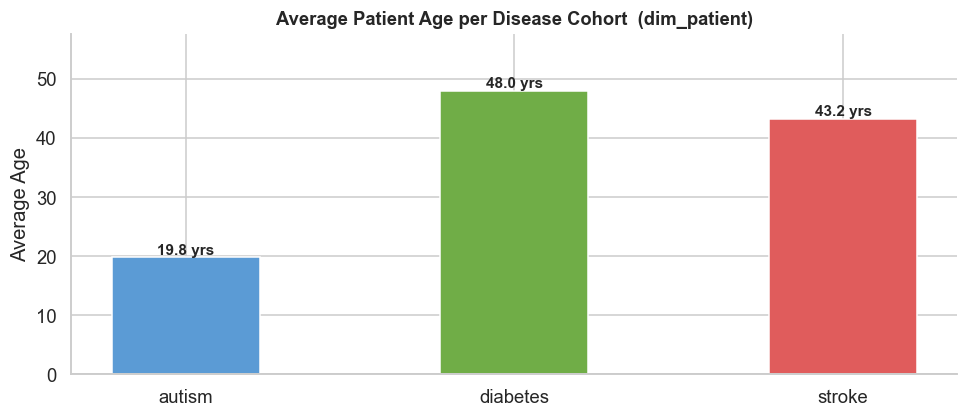

  [SAVED] reports/figures/29_sql_avg_age_per_cohort.png


In [5]:
# Q-05 : Patient Count and Age Distribution per Source Dataset

q05 = sql('''
    SELECT
        source_dataset                               AS disease_cohort,
        COUNT(*)                                     AS total_patients,
        ROUND(MIN(age),  1)                          AS min_age,
        ROUND(MAX(age),  1)                          AS max_age,
        ROUND(AVG(age),  2)                          AS avg_age,
        ROUND(100.0 * SUM(gender)     / COUNT(*), 2) AS pct_male,
        ROUND(100.0 * SUM(1 - gender) / COUNT(*), 2) AS pct_female
    FROM  dim_patient
    GROUP BY source_dataset
    ORDER BY source_dataset
''', title="Q-05: Age Distribution per Disease Cohort")

display(q05.style.format({'total_patients': '{:,}'}))

# Visualise average age
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#5B9BD5', '#70AD47', '#E05C5C']
bars = ax.bar(q05['disease_cohort'], q05['avg_age'],
              color=colors, edgecolor='white', width=0.45)
for bar, val in zip(bars, q05['avg_age']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f} yrs', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Average Patient Age per Disease Cohort  (dim_patient)')
ax.set_ylabel('Average Age')
ax.set_ylim(0, q05['avg_age'].max() * 1.2)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
savefig('29_sql_avg_age_per_cohort.png')

  Q-06: Age Bracket Roll-Up  (15 rows x 3 cols)


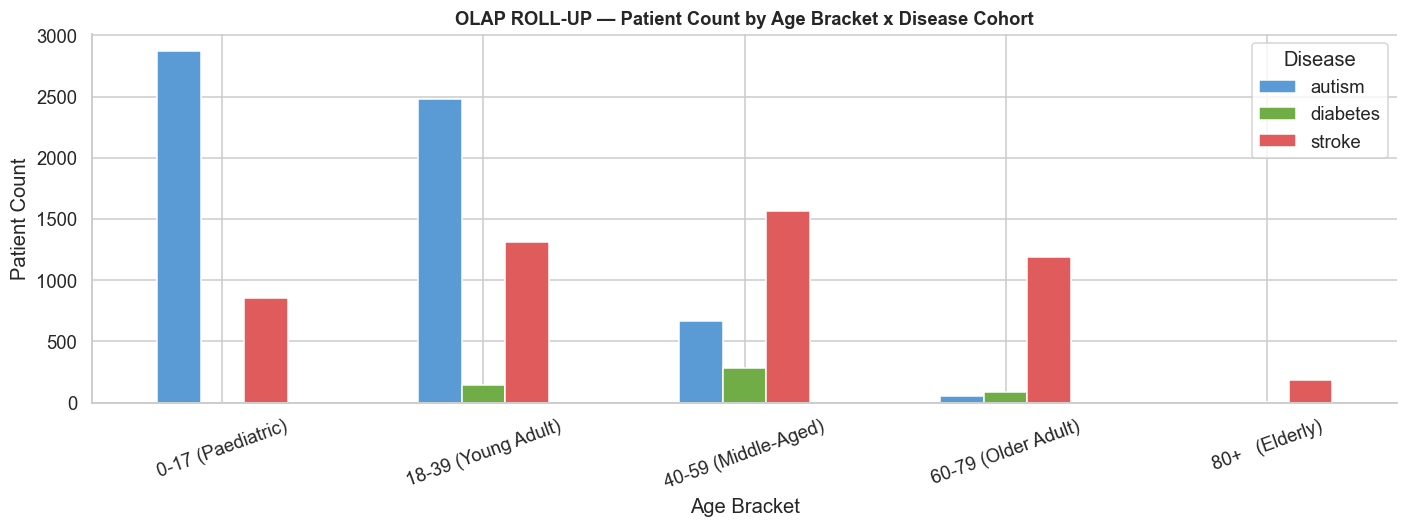

  [SAVED] reports/figures/30_sql_age_bracket_rollup.png


,disease,age_bracket,patient_count
0,autism,0-17 (Paediatric),2870
1,autism,18-39 (Young Adult),2483
2,autism,40-59 (Middle-Aged),667
3,autism,60-79 (Older Adult),54
4,autism,80+ (Elderly),1
5,diabetes,0-17 (Paediatric),1
6,diabetes,18-39 (Young Adult),143
7,diabetes,40-59 (Middle-Aged),281
8,diabetes,60-79 (Older Adult),91
9,diabetes,80+ (Elderly),4


In [6]:
# Q-06 : Age Bracket Distribution  (OLAP ROLL-UP: patient -> age bracket)

q06 = sql('''
    SELECT
        source_dataset   AS disease,
        CASE
            WHEN age <  18               THEN '0-17 (Paediatric)'
            WHEN age >= 18 AND age <  40 THEN '18-39 (Young Adult)'
            WHEN age >= 40 AND age <  60 THEN '40-59 (Middle-Aged)'
            WHEN age >= 60 AND age <  80 THEN '60-79 (Older Adult)'
            ELSE                              '80+   (Elderly)'
        END              AS age_bracket,
        COUNT(*)         AS patient_count
    FROM  dim_patient
    GROUP BY source_dataset, age_bracket
    ORDER BY source_dataset, age_bracket
''', title="Q-06: Age Bracket Roll-Up")

# Pivot for visualisation
pivot = q06.pivot(index='age_bracket', columns='disease',
                  values='patient_count').fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(13, 5))
pivot.plot(kind='bar', ax=ax,
           color=['#5B9BD5','#70AD47','#E05C5C'],
           edgecolor='white', rot=20)
ax.set_title('OLAP ROLL-UP — Patient Count by Age Bracket x Disease Cohort')
ax.set_ylabel('Patient Count')
ax.set_xlabel('Age Bracket')
ax.legend(title='Disease')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
savefig('30_sql_age_bracket_rollup.png')

display(q06)

  Q-07: Gender Balance  (3 rows x 7 cols)


,disease,male_count,female_count,total,pct_male,pct_female,gender_balance
0,autism,"3,508","2,567","6,075",57.740000,42.260000,Balanced
1,diabetes,328,192,520,63.080000,36.920000,Imbalanced
2,stroke,"2,115","2,994","5,109",41.400000,58.600000,Balanced


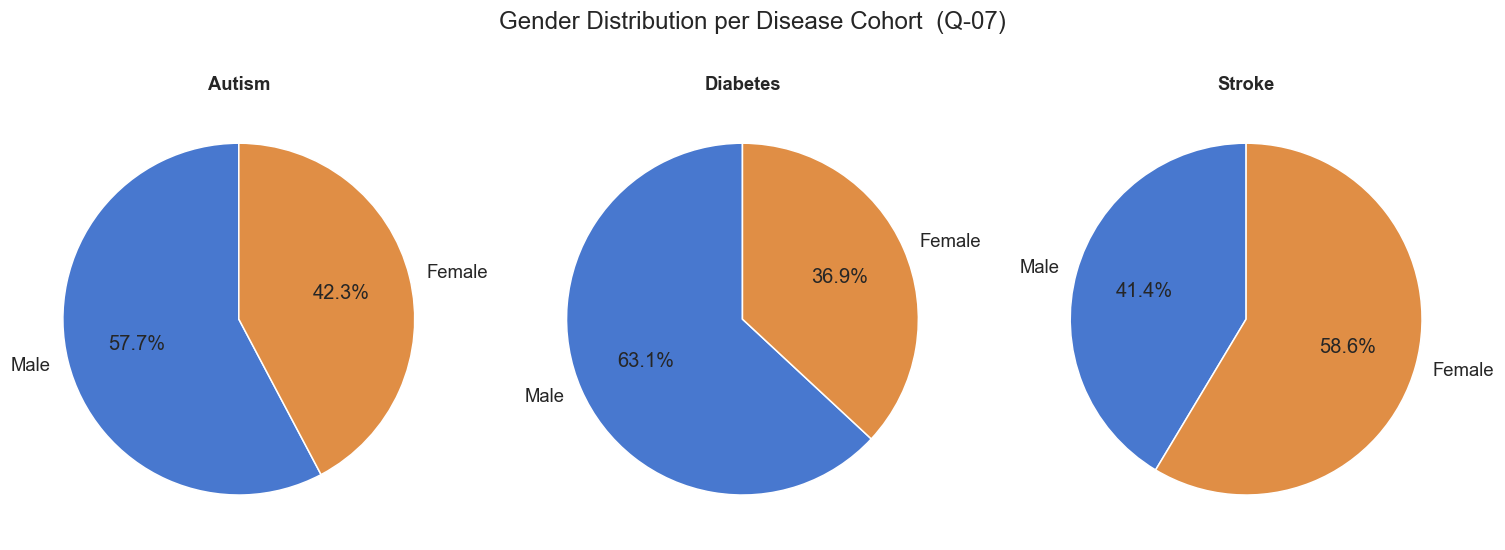

  [SAVED] reports/figures/31_sql_gender_distribution.png


In [7]:
# Q-07 : Gender Balance per Disease Cohort

q07 = sql('''
    SELECT
        source_dataset                               AS disease,
        SUM(gender)                                  AS male_count,
        SUM(1 - gender)                              AS female_count,
        COUNT(*)                                     AS total,
        ROUND(100.0 * SUM(gender)     / COUNT(*), 2) AS pct_male,
        ROUND(100.0 * SUM(1 - gender) / COUNT(*), 2) AS pct_female,
        CASE
            WHEN ABS(50.0 - 100.0 * SUM(gender) / COUNT(*)) < 10
            THEN 'Balanced'
            ELSE 'Imbalanced'
        END                                          AS gender_balance
    FROM  dim_patient
    GROUP BY source_dataset
    ORDER BY source_dataset
''', title="Q-07: Gender Balance")

display(q07.style.format({'male_count': '{:,}', 'female_count': '{:,}',
                           'total': '{:,}'}))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Gender Distribution per Disease Cohort  (Q-07)', y=1.02)
for ax, (_, row) in zip(axes, q07.iterrows()):
    ax.pie([row['male_count'], row['female_count']],
           labels=['Male', 'Female'],
           colors=['#4878CF', '#E08E45'],
           autopct='%1.1f%%', startangle=90)
    ax.set_title(row['disease'].title())
plt.tight_layout()
savefig('31_sql_gender_distribution.png')

---
## Section 3 — Disease Prevalence  (OLAP)

Queries Q-08 to Q-10 operate on the `vw_disease_summary` view and the
three fact tables to produce prevalence statistics.

- **Q-08** is the executive dashboard query — single result set, all KPIs.
- **Q-09** automatically classifies each dataset's imbalance severity
  and recommends the appropriate ML resampling strategy.
- **Q-10** is a SLICE operation comparing demographics between positive
  and negative cases within each disease.

  Q-08: Global Disease Prevalence Dashboard  (3 rows x 8 cols)


,disease,total_patients,positive_cases,negative_cases,positive_rate_pct,imbalance_ratio,avg_age,pct_male
0,diabetes,520,320,200,61.54%,0.63:1,48.000000,63.100000
1,autism,"6,075","1,804","4,271",29.70%,2.37:1,19.800000,57.700000
2,stroke,"5,109",249,"4,860",4.87%,19.52:1,43.200000,41.400000


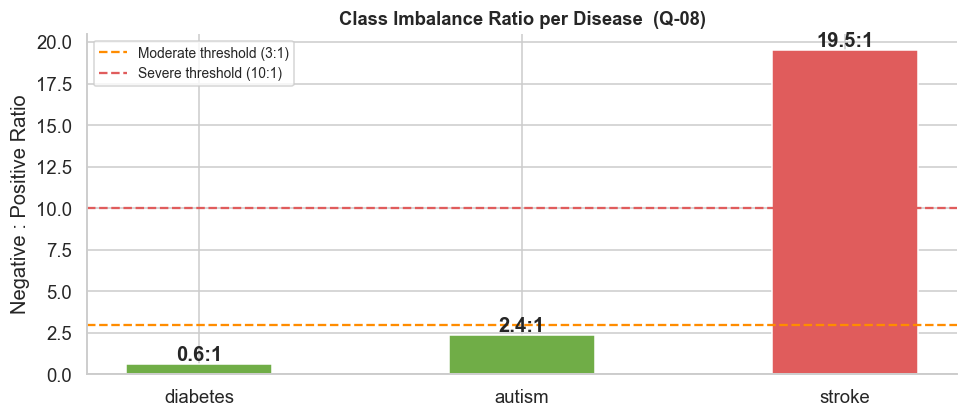

  [SAVED] reports/figures/32_sql_imbalance_ratio.png


In [8]:
# Q-08 : Global Disease Prevalence Dashboard  (vw_disease_summary)

q08 = sql('''
    SELECT
        disease,
        total_patients,
        positive_cases,
        (total_patients - positive_cases)            AS negative_cases,
        positive_pct                                 AS positive_rate_pct,
        ROUND(
            CAST(total_patients - positive_cases AS REAL)
            / NULLIF(positive_cases, 0), 2)          AS imbalance_ratio,
        avg_age,
        pct_male
    FROM  vw_disease_summary
    ORDER BY positive_rate_pct DESC
''', title="Q-08: Global Disease Prevalence Dashboard")

display(q08.style
           .format({'total_patients': '{:,}',
                    'positive_cases': '{:,}',
                    'negative_cases': '{:,}',
                    'positive_rate_pct': '{:.2f}%',
                    'imbalance_ratio': '{:.2f}:1'})
           .background_gradient(subset=['positive_rate_pct'], cmap='RdYlGn_r'))

# Imbalance ratio bar chart
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#70AD47' if r < 3 else '#FF8C00' if r <= 10 else '#E05C5C'
          for r in q08['imbalance_ratio']]
bars = ax.bar(q08['disease'], q08['imbalance_ratio'],
              color=colors, edgecolor='white', width=0.45)
ax.axhline(3,  color='#FF8C00', ls='--', lw=1.5, label='Moderate threshold (3:1)')
ax.axhline(10, color='#E05C5C', ls='--', lw=1.5, label='Severe threshold (10:1)')
for bar, val in zip(bars, q08['imbalance_ratio']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}:1', ha='center', fontweight='bold')
ax.set_title('Class Imbalance Ratio per Disease  (Q-08)')
ax.set_ylabel('Negative : Positive Ratio')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
savefig('32_sql_imbalance_ratio.png')

In [9]:
# Q-09 : Class Imbalance Risk Classification with ML Strategy Recommendation

q09 = sql('''
    SELECT
        disease,
        positive_cases,
        (total_patients - positive_cases)            AS negative_cases,
        ROUND(
            CAST(total_patients - positive_cases AS REAL)
            / NULLIF(positive_cases, 0), 1)          AS neg_to_pos_ratio,
        CASE
            WHEN CAST(total_patients - positive_cases AS REAL)
                 / NULLIF(positive_cases, 0) < 3
            THEN 'MILD    - use class_weight=balanced'
            WHEN CAST(total_patients - positive_cases AS REAL)
                 / NULLIF(positive_cases, 0) BETWEEN 3 AND 10
            THEN 'MODERATE - apply SMOTE'
            ELSE 'SEVERE  - SMOTE + scale_pos_weight required'
        END                                          AS recommended_strategy
    FROM  vw_disease_summary
    ORDER BY neg_to_pos_ratio DESC
''', title="Q-09: Imbalance Classification + ML Strategy")

def color_strategy(val):
    if 'MILD' in str(val):    return 'background-color:#c6efce'
    if 'MODERATE' in str(val): return 'background-color:#ffeb9c'
    if 'SEVERE' in str(val):  return 'background-color:#ffc7ce'
    return ''

display(q09.style.applymap(color_strategy, subset=['recommended_strategy'])
                 .format({'positive_cases': '{:,}',
                          'negative_cases': '{:,}'}))

  Q-09: Imbalance Classification + ML Strategy  (3 rows x 5 cols)


,disease,positive_cases,negative_cases,neg_to_pos_ratio,recommended_strategy
0,stroke,249,"4,860",19.500000,SEVERE - SMOTE + scale_pos_weight required
1,autism,"1,804","4,271",2.400000,MILD - use class_weight=balanced
2,diabetes,320,200,0.600000,MILD - use class_weight=balanced


  Q-10: Positive vs Negative Demographics  (6 rows x 5 cols)


,disease,diagnosis,n,avg_age,pct_male
0,autism,Negative,"4,271",19.100000,59.000000
1,autism,Positive,"1,804",21.500000,54.900000
2,diabetes,Negative,200,46.400000,90.500000
3,diabetes,Positive,320,49.100000,45.900000
4,stroke,No Stroke,"4,860",42.000000,41.300000
5,stroke,Stroke,249,67.700000,43.400000


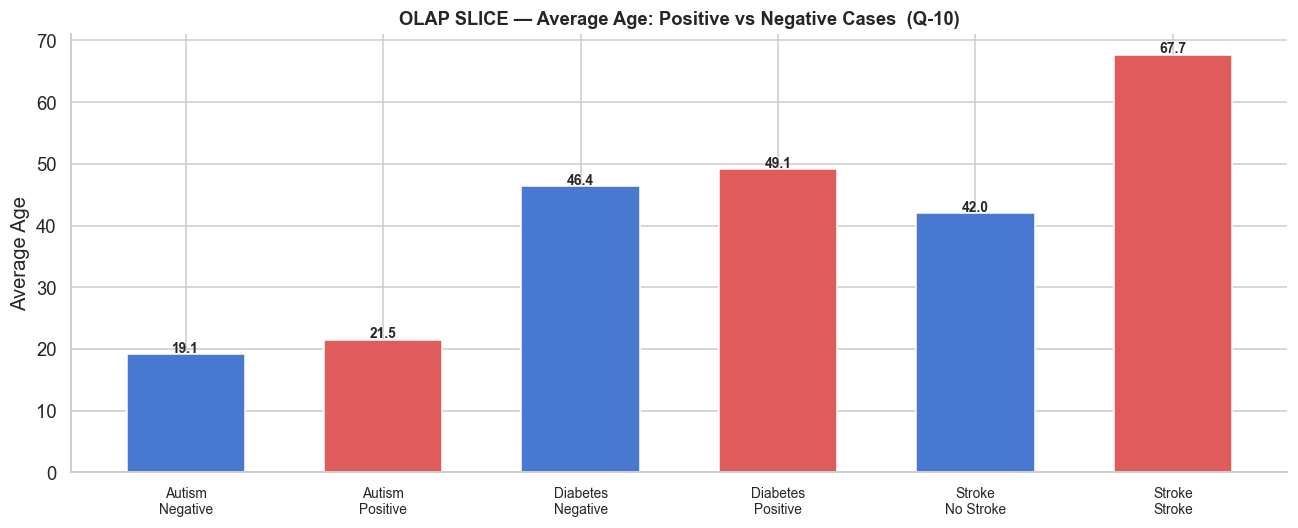

  [SAVED] reports/figures/33_sql_positive_vs_negative_age.png


In [10]:
# Q-10 : SLICE — Positive vs Negative Patient Demographics per Disease

q10 = sql('''
    SELECT 'autism' AS disease,
           CASE fa.label WHEN 1 THEN 'Positive' ELSE 'Negative' END AS diagnosis,
           COUNT(*) AS n,
           ROUND(AVG(dp.age), 1) AS avg_age,
           ROUND(100.0 * SUM(dp.gender) / COUNT(*), 1) AS pct_male
    FROM  fact_autism fa
    JOIN  dim_patient dp ON fa.patient_id = dp.patient_id
    GROUP BY fa.label
    UNION ALL
    SELECT 'diabetes',
           CASE fd.label WHEN 1 THEN 'Positive' ELSE 'Negative' END,
           COUNT(*), ROUND(AVG(dp.age),1),
           ROUND(100.0*SUM(dp.gender)/COUNT(*),1)
    FROM  fact_diabetes fd
    JOIN  dim_patient dp ON fd.patient_id = dp.patient_id
    GROUP BY fd.label
    UNION ALL
    SELECT 'stroke',
           CASE fs.label WHEN 1 THEN 'Stroke' ELSE 'No Stroke' END,
           COUNT(*), ROUND(AVG(dp.age),1),
           ROUND(100.0*SUM(dp.gender)/COUNT(*),1)
    FROM  fact_stroke fs
    JOIN  dim_patient dp ON fs.patient_id = dp.patient_id
    GROUP BY fs.label
    ORDER BY disease, diagnosis
''', title="Q-10: Positive vs Negative Demographics")

display(q10.style.format({'n': '{:,}'}))

# Age comparison bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(q10))
colors = ['#E05C5C' if 'Positive' in str(d) or d == 'Stroke'
          else '#4878CF' for d in q10['diagnosis']]
bars = ax.bar(x, q10['avg_age'], color=colors, edgecolor='white', width=0.6)
ax.set_xticks(list(x))
ax.set_xticklabels(
    [row['disease'].title() + "\n" + row['diagnosis'] for _, row in q10.iterrows()],
    fontsize=9)
ax.set_ylabel('Average Age')
ax.set_title('OLAP SLICE — Average Age: Positive vs Negative Cases  (Q-10)')
for bar, val in zip(bars, q10['avg_age']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
savefig('33_sql_positive_vs_negative_age.png')

---
## Section 4 — Disease-Specific Deep Dives  (Drill-Down)

These queries **drill down** from the cohort-level summaries produced in
Section 3 into granular feature-level statistics inside each fact table.

- **Q-11** analyses AQ Score statistics per ASD diagnosis group.
- **Q-12** ranks all 10 AQ-10 items by discriminative power.
- **Q-13** ranks all 14 diabetes symptoms by their prevalence gap.
- **Q-14** profiles clinical measurements for stroke vs non-stroke patients.

  Q-11: AQ Score by ASD Diagnosis  (2 rows x 7 cols)


,diagnosis,n,min_aq,max_aq,avg_aq,above_threshold_6,pct_above_threshold
0,ASD Positive,"1,804",7,10,8.160000,"1,804",100.0%
1,ASD Negative,"4,271",0,10,4.110000,"1,076",25.2%


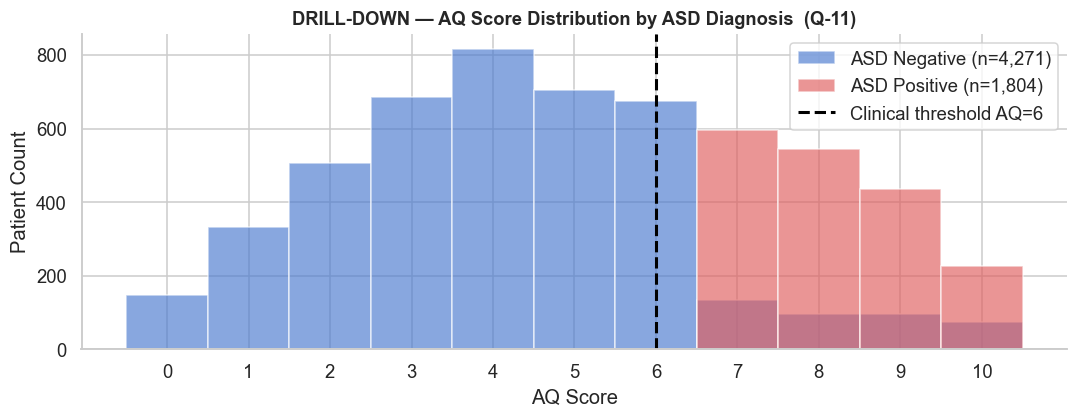

  [SAVED] reports/figures/34_sql_aq_score_distribution.png


In [11]:
# Q-11 : Autism — AQ Score Statistics by Diagnosis (DRILL-DOWN)

q11 = sql('''
    SELECT
        CASE label WHEN 1 THEN 'ASD Positive' ELSE 'ASD Negative' END AS diagnosis,
        COUNT(*)                                                        AS n,
        MIN(aq_score)                                                   AS min_aq,
        MAX(aq_score)                                                   AS max_aq,
        ROUND(AVG(aq_score), 2)                                         AS avg_aq,
        SUM(CASE WHEN aq_score >= 6 THEN 1 ELSE 0 END)                 AS above_threshold_6,
        ROUND(100.0 * SUM(CASE WHEN aq_score >= 6 THEN 1 ELSE 0 END)
              / COUNT(*), 1)                                            AS pct_above_threshold
    FROM  fact_autism
    GROUP BY label
    ORDER BY label DESC
''', title="Q-11: AQ Score by ASD Diagnosis")

display(q11.style.format({'n': '{:,}', 'above_threshold_6': '{:,}',
                           'pct_above_threshold': '{:.1f}%'}))

# AQ Score distribution comparison
q11_dist = pd.read_sql_query('''
    SELECT aq_score, label FROM fact_autism
''', conn)

fig, ax = plt.subplots(figsize=(10, 4))
for lbl, name, color in [(0,'ASD Negative','#4878CF'),(1,'ASD Positive','#E05C5C')]:
    subset = q11_dist[q11_dist['label'] == lbl]['aq_score']
    ax.hist(subset, bins=range(0, 12), alpha=0.65,
            label=f'{name} (n={len(subset):,})', color=color,
            edgecolor='white', align='left')
ax.axvline(6, color='black', ls='--', lw=2, label='Clinical threshold AQ=6')
ax.set_xlabel('AQ Score')
ax.set_ylabel('Patient Count')
ax.set_title('DRILL-DOWN — AQ Score Distribution by ASD Diagnosis  (Q-11)')
ax.set_xticks(range(0, 11))
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
savefig('34_sql_aq_score_distribution.png')

In [12]:
# Q-12 : Autism — AQ-10 Item Response Rates by Diagnosis

q12 = sql('''
    SELECT 'A1'  AS item,
           ROUND(AVG(CASE WHEN label=1 THEN a1  END)*100,1) AS pct_pos,
           ROUND(AVG(CASE WHEN label=0 THEN a1  END)*100,1) AS pct_neg,
           ROUND((AVG(CASE WHEN label=1 THEN a1  END)
                - AVG(CASE WHEN label=0 THEN a1  END))*100,1) AS gap_pp
    FROM fact_autism UNION ALL
    SELECT 'A2',  ROUND(AVG(CASE WHEN label=1 THEN a2  END)*100,1),
                  ROUND(AVG(CASE WHEN label=0 THEN a2  END)*100,1),
                  ROUND((AVG(CASE WHEN label=1 THEN a2  END)
                       - AVG(CASE WHEN label=0 THEN a2  END))*100,1)
    FROM fact_autism UNION ALL
    SELECT 'A3',  ROUND(AVG(CASE WHEN label=1 THEN a3  END)*100,1),
                  ROUND(AVG(CASE WHEN label=0 THEN a3  END)*100,1),
                  ROUND((AVG(CASE WHEN label=1 THEN a3  END)
                       - AVG(CASE WHEN label=0 THEN a3  END))*100,1)
    FROM fact_autism UNION ALL
    SELECT 'A4',  ROUND(AVG(CASE WHEN label=1 THEN a4  END)*100,1),
                  ROUND(AVG(CASE WHEN label=0 THEN a4  END)*100,1),
                  ROUND((AVG(CASE WHEN label=1 THEN a4  END)
                       - AVG(CASE WHEN label=0 THEN a4  END))*100,1)
    FROM fact_autism UNION ALL
    SELECT 'A5',  ROUND(AVG(CASE WHEN label=1 THEN a5  END)*100,1),
                  ROUND(AVG(CASE WHEN label=0 THEN a5  END)*100,1),
                  ROUND((AVG(CASE WHEN label=1 THEN a5  END)
                       - AVG(CASE WHEN label=0 THEN a5  END))*100,1)
    FROM fact_autism UNION ALL
    SELECT 'A6',  ROUND(AVG(CASE WHEN label=1 THEN a6  END)*100,1),
                  ROUND(AVG(CASE WHEN label=0 THEN a6  END)*100,1),
                  ROUND((AVG(CASE WHEN label=1 THEN a6  END)
                       - AVG(CASE WHEN label=0 THEN a6  END))*100,1)
    FROM fact_autism UNION ALL
    SELECT 'A7',  ROUND(AVG(CASE WHEN label=1 THEN a7  END)*100,1),
                  ROUND(AVG(CASE WHEN label=0 THEN a7  END)*100,1),
                  ROUND((AVG(CASE WHEN label=1 THEN a7  END)
                       - AVG(CASE WHEN label=0 THEN a7  END))*100,1)
    FROM fact_autism UNION ALL
    SELECT 'A8',  ROUND(AVG(CASE WHEN label=1 THEN a8  END)*100,1),
                  ROUND(AVG(CASE WHEN label=0 THEN a8  END)*100,1),
                  ROUND((AVG(CASE WHEN label=1 THEN a8  END)
                       - AVG(CASE WHEN label=0 THEN a8  END))*100,1)
    FROM fact_autism UNION ALL
    SELECT 'A9',  ROUND(AVG(CASE WHEN label=1 THEN a9  END)*100,1),
                  ROUND(AVG(CASE WHEN label=0 THEN a9  END)*100,1),
                  ROUND((AVG(CASE WHEN label=1 THEN a9  END)
                       - AVG(CASE WHEN label=0 THEN a9  END))*100,1)
    FROM fact_autism UNION ALL
    SELECT 'A10', ROUND(AVG(CASE WHEN label=1 THEN a10 END)*100,1),
                  ROUND(AVG(CASE WHEN label=0 THEN a10 END)*100,1),
                  ROUND((AVG(CASE WHEN label=1 THEN a10 END)
                       - AVG(CASE WHEN label=0 THEN a10 END))*100,1)
    FROM fact_autism
    ORDER BY gap_pp DESC
''', title="Q-12: AQ-10 Item Discriminative Power")

display(q12.style
           .background_gradient(subset=['gap_pp'], cmap='RdYlGn')
           .format({'pct_pos': '{:.1f}%', 'pct_neg': '{:.1f}%',
                    'gap_pp': '{:+.1f} pp'}))

  Q-12: AQ-10 Item Discriminative Power  (10 rows x 4 cols)

,item,pct_pos,pct_neg,gap_pp
0,A6,82.0%,28.4%,+53.6 pp
1,A9,79.3%,27.7%,+51.6 pp
2,A5,89.9%,39.4%,+50.5 pp
3,A4,87.1%,41.1%,+46.1 pp
4,A3,85.6%,40.3%,+45.4 pp
5,A10,89.4%,47.6%,+41.8 pp
6,A8,76.6%,44.3%,+32.3 pp
7,A7,70.2%,41.2%,+29.0 pp
8,A2,68.3%,40.1%,+28.2 pp
9,A1,87.9%,61.5%,+26.4 pp


  Q-13: Diabetes Symptom Discriminative Power Ranking  (14 rows x 5 cols)


,symptom,pct_in_diabetic,pct_in_healthy,gap_pp,discriminative_power
0,polyuria,75.9%,7.5%,+68.4 pp,HIGH
1,polydipsia,70.3%,4.0%,+66.3 pp,HIGH
2,sudden_weight_loss,58.8%,14.5%,+44.3 pp,HIGH
3,partial_paresis,60.0%,16.0%,+44.0 pp,HIGH
4,polyphagia,59.1%,24.0%,+35.1 pp,HIGH
5,irritability,34.4%,8.0%,+26.4 pp,MODERATE
6,visual_blurring,54.7%,29.0%,+25.7 pp,MODERATE
7,weakness,68.1%,43.5%,+24.6 pp,MODERATE
8,muscle_stiffness,42.2%,30.0%,+12.2 pp,LOW
9,genital_thrush,25.9%,16.5%,+9.4 pp,LOW


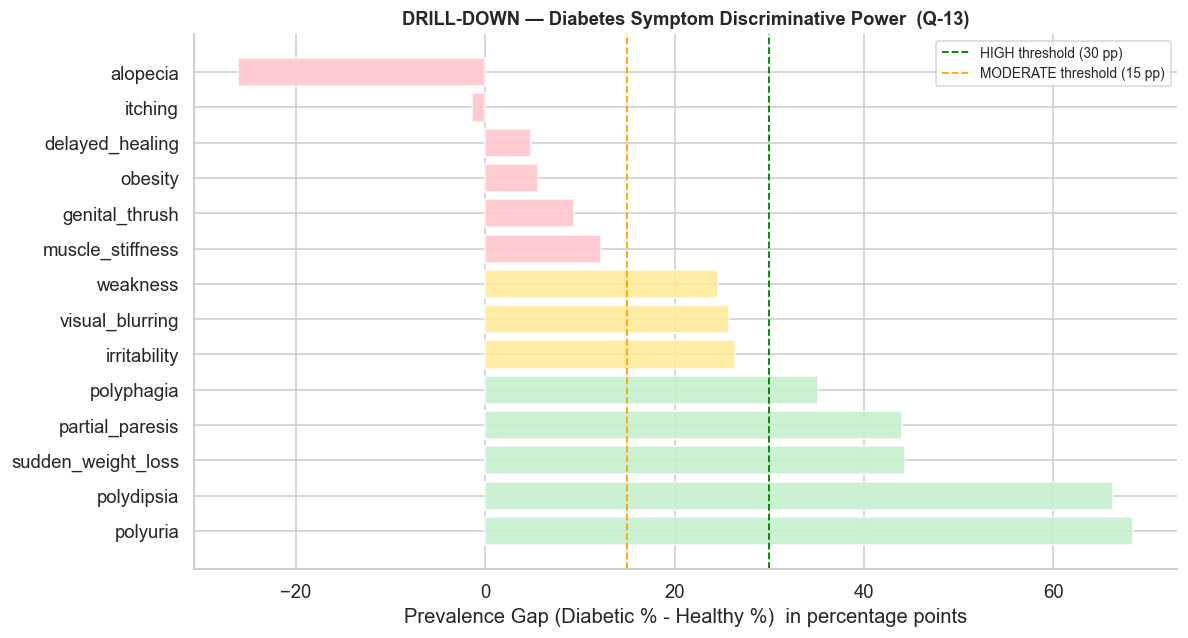

  [SAVED] reports/figures/35_sql_diabetes_symptom_gap.png


In [13]:
# Q-13 : Diabetes — Symptom Prevalence Gap Ranking  (DRILL-DOWN)

q13 = sql('''
    SELECT symptom,
           ROUND(pct_positive,1) AS pct_in_diabetic,
           ROUND(pct_negative,1) AS pct_in_healthy,
           ROUND(pct_positive - pct_negative,1) AS gap_pp,
           CASE
               WHEN (pct_positive-pct_negative)>30 THEN 'HIGH'
               WHEN (pct_positive-pct_negative)>15 THEN 'MODERATE'
               ELSE                                     'LOW'
           END AS discriminative_power
    FROM (
        SELECT 'polyuria'         AS symptom,
               AVG(CASE WHEN label=1 THEN polyuria*100.0          END) AS pct_positive,
               AVG(CASE WHEN label=0 THEN polyuria*100.0          END) AS pct_negative
        FROM fact_diabetes UNION ALL
        SELECT 'polydipsia',
               AVG(CASE WHEN label=1 THEN polydipsia*100.0        END),
               AVG(CASE WHEN label=0 THEN polydipsia*100.0        END) FROM fact_diabetes UNION ALL
        SELECT 'sudden_weight_loss',
               AVG(CASE WHEN label=1 THEN sudden_weight_loss*100.0 END),
               AVG(CASE WHEN label=0 THEN sudden_weight_loss*100.0 END) FROM fact_diabetes UNION ALL
        SELECT 'weakness',
               AVG(CASE WHEN label=1 THEN weakness*100.0          END),
               AVG(CASE WHEN label=0 THEN weakness*100.0          END) FROM fact_diabetes UNION ALL
        SELECT 'polyphagia',
               AVG(CASE WHEN label=1 THEN polyphagia*100.0        END),
               AVG(CASE WHEN label=0 THEN polyphagia*100.0        END) FROM fact_diabetes UNION ALL
        SELECT 'visual_blurring',
               AVG(CASE WHEN label=1 THEN visual_blurring*100.0   END),
               AVG(CASE WHEN label=0 THEN visual_blurring*100.0   END) FROM fact_diabetes UNION ALL
        SELECT 'partial_paresis',
               AVG(CASE WHEN label=1 THEN partial_paresis*100.0   END),
               AVG(CASE WHEN label=0 THEN partial_paresis*100.0   END) FROM fact_diabetes UNION ALL
        SELECT 'itching',
               AVG(CASE WHEN label=1 THEN itching*100.0           END),
               AVG(CASE WHEN label=0 THEN itching*100.0           END) FROM fact_diabetes UNION ALL
        SELECT 'muscle_stiffness',
               AVG(CASE WHEN label=1 THEN muscle_stiffness*100.0  END),
               AVG(CASE WHEN label=0 THEN muscle_stiffness*100.0  END) FROM fact_diabetes UNION ALL
        SELECT 'irritability',
               AVG(CASE WHEN label=1 THEN irritability*100.0      END),
               AVG(CASE WHEN label=0 THEN irritability*100.0      END) FROM fact_diabetes UNION ALL
        SELECT 'alopecia',
               AVG(CASE WHEN label=1 THEN alopecia*100.0          END),
               AVG(CASE WHEN label=0 THEN alopecia*100.0          END) FROM fact_diabetes UNION ALL
        SELECT 'obesity',
               AVG(CASE WHEN label=1 THEN obesity*100.0           END),
               AVG(CASE WHEN label=0 THEN obesity*100.0           END) FROM fact_diabetes UNION ALL
        SELECT 'delayed_healing',
               AVG(CASE WHEN label=1 THEN delayed_healing*100.0   END),
               AVG(CASE WHEN label=0 THEN delayed_healing*100.0   END) FROM fact_diabetes UNION ALL
        SELECT 'genital_thrush',
               AVG(CASE WHEN label=1 THEN genital_thrush*100.0    END),
               AVG(CASE WHEN label=0 THEN genital_thrush*100.0    END) FROM fact_diabetes
    ) ORDER BY gap_pp DESC
''', title="Q-13: Diabetes Symptom Discriminative Power Ranking")

def color_power(val):
    if val == 'HIGH':     return 'background-color:#c6efce; font-weight:bold'
    if val == 'MODERATE': return 'background-color:#ffeb9c'
    return 'background-color:#ffc7ce'

display(q13.style
           .applymap(color_power, subset=['discriminative_power'])
           .format({'pct_in_diabetic': '{:.1f}%',
                    'pct_in_healthy' : '{:.1f}%',
                    'gap_pp'         : '{:+.1f} pp'}))

# Horizontal bar chart of gaps
fig, ax = plt.subplots(figsize=(11, 6))
colors_bar = ['#c6efce' if p=='HIGH' else '#ffeb9c' if p=='MODERATE'
              else '#ffc7ce' for p in q13['discriminative_power']]
ax.barh(q13['symptom'], q13['gap_pp'],
        color=colors_bar, edgecolor='white', alpha=0.9)
ax.axvline(30, color='green',  ls='--', lw=1.2, label='HIGH threshold (30 pp)')
ax.axvline(15, color='orange', ls='--', lw=1.2, label='MODERATE threshold (15 pp)')
ax.set_xlabel('Prevalence Gap (Diabetic % - Healthy %)  in percentage points')
ax.set_title('DRILL-DOWN — Diabetes Symptom Discriminative Power  (Q-13)')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
savefig('35_sql_diabetes_symptom_gap.png')

In [14]:
# Q-14 : Stroke — Clinical Risk Profile by Outcome  (DRILL-DOWN)

q14 = sql('''
    SELECT
        CASE label WHEN 1 THEN 'Stroke' ELSE 'No Stroke' END AS outcome,
        COUNT(*)                                              AS n,
        ROUND(AVG(dp.age),               1) AS avg_age,
        ROUND(AVG(fs.avg_glucose_level), 2) AS avg_glucose_mg_dl,
        ROUND(AVG(fs.bmi),               2) AS avg_bmi,
        ROUND(100.0 * SUM(fs.hypertension)  / COUNT(*), 1) AS pct_hypertension,
        ROUND(100.0 * SUM(fs.heart_disease) / COUNT(*), 1) AS pct_heart_disease,
        ROUND(100.0 * SUM(fs.ever_married)  / COUNT(*), 1) AS pct_ever_married,
        ROUND(100.0 * SUM(fs.residence_type)/ COUNT(*), 1) AS pct_urban
    FROM  fact_stroke fs
    JOIN  dim_patient dp ON fs.patient_id = dp.patient_id
    GROUP BY fs.label
    ORDER BY fs.label DESC
''', title="Q-14: Stroke Clinical Risk Profile")

display(q14.style
           .format({'n': '{:,}'})
           .highlight_max(subset=['avg_age','avg_glucose_mg_dl','avg_bmi',
                                  'pct_hypertension','pct_heart_disease'],
                          color='#ffc7ce'))

print()
print("Key clinical differences (Stroke vs No-Stroke):")
stroke    = q14[q14['outcome'] == 'Stroke'].iloc[0]
no_stroke = q14[q14['outcome'] == 'No Stroke'].iloc[0]
print(f"  Age           : {stroke['avg_age']:.1f} vs {no_stroke['avg_age']:.1f}  (+{stroke['avg_age']-no_stroke['avg_age']:.1f} yrs)")
print(f"  Glucose       : {stroke['avg_glucose_mg_dl']:.1f} vs {no_stroke['avg_glucose_mg_dl']:.1f}  (+{stroke['avg_glucose_mg_dl']-no_stroke['avg_glucose_mg_dl']:.1f} mg/dL)")
print(f"  Hypertension  : {stroke['pct_hypertension']:.1f}% vs {no_stroke['pct_hypertension']:.1f}%")
print(f"  Heart Disease : {stroke['pct_heart_disease']:.1f}% vs {no_stroke['pct_heart_disease']:.1f}%")

  Q-14: Stroke Clinical Risk Profile  (2 rows x 9 cols)


,outcome,n,avg_age,avg_glucose_mg_dl,avg_bmi,pct_hypertension,pct_heart_disease,pct_ever_married,pct_urban
0,Stroke,249,67.700000,132.540000,30.270000,26.500000,18.900000,88.400000,54.200000
1,No Stroke,"4,860",42.000000,104.790000,28.800000,8.900000,4.700000,64.500000,50.600000



Key clinical differences (Stroke vs No-Stroke):
  Age           : 67.7 vs 42.0  (+25.7 yrs)
  Glucose       : 132.5 vs 104.8  (+27.7 mg/dL)
  Hypertension  : 26.5% vs 8.9%
  Heart Disease : 18.9% vs 4.7%


---
## Section 5 — Cross-Disease JOIN Analysis

These queries demonstrate the **core value of the star schema**: the ability
to join multiple fact tables back to `dim_patient` in a single query,
enabling cross-disease population analysis that would be impossible in
three separate flat files.

- **Q-15** is a DICE on `fact_stroke` by smoking_status.
- **Q-16** is a DICE on two binary dimensions: hypertension × heart_disease.
- **Q-17** is the unified warehouse query — all four tables in one SELECT.

  Q-15: Stroke Rate by Smoking Status (DICE)  (4 rows x 6 cols)


,smoking_status,total_patients,stroke_cases,no_stroke_cases,stroke_rate_pct,vs_average
0,formerly smoked,884,70,814,7.92%,ABOVE average risk
1,smokes,789,42,747,5.32%,ABOVE average risk
2,never smoked,"1,892",90,"1,802",4.76%,Below average risk
3,Unknown,"1,544",47,"1,497",3.04%,Below average risk


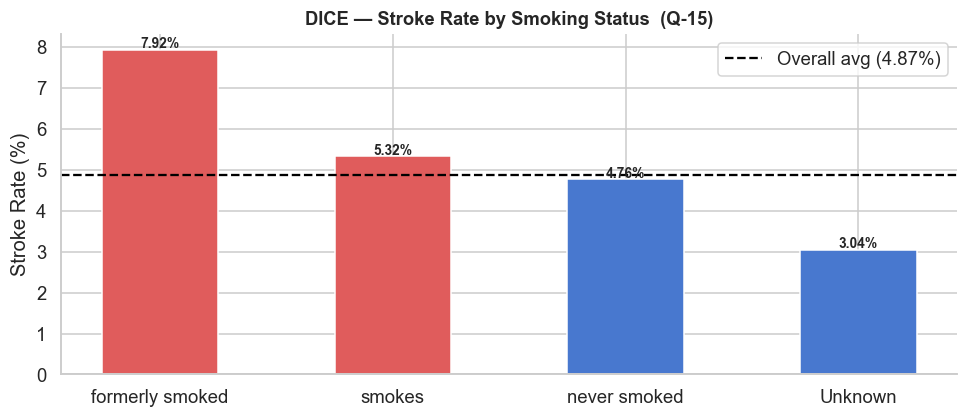

  [SAVED] reports/figures/36_sql_smoking_stroke_rate.png


In [15]:
# Q-15 : DICE — Stroke Rate by Smoking Status

q15 = sql('''
    SELECT
        smoking_status,
        COUNT(*)                                            AS total_patients,
        SUM(label)                                          AS stroke_cases,
        COUNT(*) - SUM(label)                               AS no_stroke_cases,
        ROUND(100.0 * SUM(label) / COUNT(*), 2)             AS stroke_rate_pct,
        CASE
            WHEN ROUND(100.0*SUM(label)/COUNT(*),2) >
                 (SELECT ROUND(100.0*SUM(label)/COUNT(*),2) FROM fact_stroke)
            THEN 'ABOVE average risk'
            ELSE 'Below average risk'
        END                                                 AS vs_average
    FROM  fact_stroke
    GROUP BY smoking_status
    ORDER BY stroke_rate_pct DESC
''', title="Q-15: Stroke Rate by Smoking Status (DICE)")

display(q15.style
           .format({'total_patients': '{:,}', 'stroke_cases': '{:,}',
                    'no_stroke_cases': '{:,}', 'stroke_rate_pct': '{:.2f}%'})
           .applymap(lambda v: 'background-color:#ffc7ce; font-weight:bold'
                     if v == 'ABOVE average risk' else '',
                     subset=['vs_average']))

fig, ax = plt.subplots(figsize=(9, 4))
avg_rate = pd.read_sql_query(
    'SELECT ROUND(100.0*SUM(label)/COUNT(*),2) AS r FROM fact_stroke', conn
).iloc[0]['r']
colors_bar = ['#E05C5C' if v > avg_rate else '#4878CF'
              for v in q15['stroke_rate_pct']]
bars = ax.bar(q15['smoking_status'], q15['stroke_rate_pct'],
              color=colors_bar, edgecolor='white', width=0.5)
ax.axhline(avg_rate, color='black', ls='--', lw=1.5,
           label=f'Overall avg ({avg_rate:.2f}%)')
for bar, val in zip(bars, q15['stroke_rate_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Stroke Rate (%)')
ax.set_title('DICE — Stroke Rate by Smoking Status  (Q-15)')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
savefig('36_sql_smoking_stroke_rate.png')

In [16]:
# Q-16 : DICE — Stroke Rate: Hypertension x Heart Disease Matrix

q16 = sql('''
    SELECT
        CASE hypertension  WHEN 1 THEN 'HTN: Yes' ELSE 'HTN: No'  END AS hypertension_status,
        CASE heart_disease WHEN 1 THEN 'HD: Yes'  ELSE 'HD: No'   END AS heart_disease_status,
        COUNT(*)                                                        AS total_patients,
        SUM(label)                                                      AS stroke_cases,
        ROUND(100.0 * SUM(label) / COUNT(*), 2)                        AS stroke_rate_pct
    FROM  fact_stroke
    GROUP BY hypertension, heart_disease
    ORDER BY stroke_rate_pct DESC
''', title="Q-16: Comorbidity Matrix (Hypertension x Heart Disease)")

display(q16.style
           .format({'total_patients': '{:,}', 'stroke_cases': '{:,}',
                    'stroke_rate_pct': '{:.2f}%'})
           .background_gradient(subset=['stroke_rate_pct'], cmap='Reds'))

print()
high_risk = q16.iloc[0]
print(f"Highest risk subgroup: {high_risk['hypertension_status']} + {high_risk['heart_disease_status']}")
print(f"  Stroke rate: {high_risk['stroke_rate_pct']:.2f}%  ({int(high_risk['stroke_cases'])} strokes / {int(high_risk['total_patients'])} patients)")

  Q-16: Comorbidity Matrix (Hypertension x Heart Disease)  (4 rows x 5 cols)


,hypertension_status,heart_disease_status,total_patients,stroke_cases,stroke_rate_pct
0,HTN: Yes,HD: Yes,64,13,20.31%
1,HTN: No,HD: Yes,212,34,16.04%
2,HTN: Yes,HD: No,434,53,12.21%
3,HTN: No,HD: No,"4,399",149,3.39%



Highest risk subgroup: HTN: Yes + HD: Yes
  Stroke rate: 20.31%  (13 strokes / 64 patients)


In [17]:
# Q-17 : Unified Warehouse Query — All 4 Tables in One SELECT

q17 = sql('''
    SELECT 'Autism Screening' AS disease, COUNT(*) AS total,
           SUM(fa.label) AS positives,
           ROUND(AVG(dp.age),1) AS avg_age,
           ROUND(100.0*SUM(dp.gender)/COUNT(*),1) AS pct_male,
           ROUND(100.0*SUM(fa.label)/COUNT(*),2) AS prevalence_pct,
           'AQ_Score >= 6' AS primary_risk_indicator
    FROM  fact_autism fa JOIN dim_patient dp ON fa.patient_id=dp.patient_id
    UNION ALL
    SELECT 'Diabetes Risk', COUNT(*), SUM(fd.label),
           ROUND(AVG(dp.age),1), ROUND(100.0*SUM(dp.gender)/COUNT(*),1),
           ROUND(100.0*SUM(fd.label)/COUNT(*),2), 'Polyuria + Polydipsia'
    FROM  fact_diabetes fd JOIN dim_patient dp ON fd.patient_id=dp.patient_id
    UNION ALL
    SELECT 'Stroke Prediction', COUNT(*), SUM(fs.label),
           ROUND(AVG(dp.age),1), ROUND(100.0*SUM(dp.gender)/COUNT(*),1),
           ROUND(100.0*SUM(fs.label)/COUNT(*),2), 'Age + Glucose + HTN'
    FROM  fact_stroke fs JOIN dim_patient dp ON fs.patient_id=dp.patient_id
''', title="Q-17: Unified Cross-Disease Summary (Star Schema Join)")

display(q17.style
           .format({'total': '{:,}', 'positives': '{:,}',
                    'prevalence_pct': '{:.2f}%'})
           .background_gradient(subset=['prevalence_pct'], cmap='YlOrRd'))

  Q-17: Unified Cross-Disease Summary (Star Schema Join)  (3 rows x 7 cols)


,disease,total,positives,avg_age,pct_male,prevalence_pct,primary_risk_indicator
0,Autism Screening,"6,075","1,804",19.800000,57.700000,29.70%,AQ_Score >= 6
1,Diabetes Risk,520,320,48.000000,63.100000,61.54%,Polyuria + Polydipsia
2,Stroke Prediction,"5,109",249,43.200000,41.400000,4.87%,Age + Glucose + HTN


---
## Section 6 — Advanced OLAP Operations

The final three queries demonstrate the four classical OLAP operations
defined by Codd (1993) and implemented in this SQLite warehouse:

| Operation | Definition | Query |
|---|---|---|
| **ROLL-UP** | Aggregate from fine to coarse granularity | Q-18 |
| **SLICE** | Restrict one dimension to a single value | Q-19 |
| **DICE** | Restrict two or more dimensions simultaneously | Q-20 |
| **DRILL-DOWN** | Disaggregate from coarse to fine granularity | Q-11 to Q-14 |

> Note: SQLite does not natively support `ROLLUP` or `CUBE` clauses.
> These operations are simulated using `CASE` expressions,
> `GROUP BY` combinations, and `UNION ALL`.

  Q-18: ROLL-UP — Age Bracket x Work Type (top 15)  (14 rows x 5 cols)


,age_bracket,work_type,patients,stroke_cases,stroke_rate_pct
0,80+,Govt_job,14,5,35.71%
1,80+,Private,86,21,24.42%
2,80+,Self-employed,86,14,16.28%
3,60-79,Private,637,81,12.72%
4,60-79,Self-employed,373,42,11.26%
5,60-79,Govt_job,180,18,10.00%
6,40-59,Private,"1,005",43,4.28%
7,40-59,Govt_job,306,10,3.27%
8,40-59,Self-employed,253,7,2.77%
9,Under 40,Self-employed,107,2,1.87%


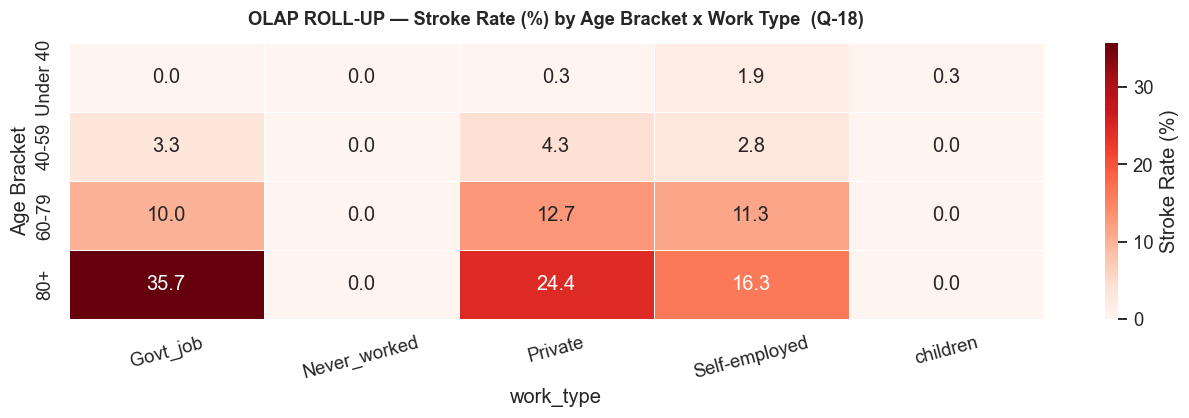

  [SAVED] reports/figures/37_sql_rollup_age_worktype_heatmap.png


In [18]:
# Q-18 : OLAP ROLL-UP — Stroke Risk by Age Bracket x Work Type

q18 = sql('''
    SELECT
        CASE
            WHEN dp.age <  40 THEN 'Under 40'
            WHEN dp.age <  60 THEN '40-59'
            WHEN dp.age <  80 THEN '60-79'
            ELSE                   '80+'
        END                                          AS age_bracket,
        fs.work_type,
        COUNT(*)                                     AS patients,
        SUM(fs.label)                                AS stroke_cases,
        ROUND(100.0 * SUM(fs.label) / COUNT(*), 2)   AS stroke_rate_pct
    FROM  fact_stroke fs
    JOIN  dim_patient dp ON fs.patient_id = dp.patient_id
    GROUP BY age_bracket, fs.work_type
    ORDER BY stroke_rate_pct DESC
    LIMIT 15
''', title="Q-18: ROLL-UP — Age Bracket x Work Type (top 15)")

display(q18.style
           .format({'patients': '{:,}', 'stroke_cases': '{:,}',
                    'stroke_rate_pct': '{:.2f}%'})
           .background_gradient(subset=['stroke_rate_pct'], cmap='Reds'))

# Pivot heatmap
q18_full = pd.read_sql_query('''
    SELECT
        CASE WHEN dp.age<40 THEN 'Under 40'
             WHEN dp.age<60 THEN '40-59'
             WHEN dp.age<80 THEN '60-79'
             ELSE '80+' END          AS age_bracket,
        fs.work_type,
        ROUND(100.0*SUM(fs.label)/COUNT(*),2) AS stroke_rate_pct
    FROM fact_stroke fs JOIN dim_patient dp ON fs.patient_id=dp.patient_id
    GROUP BY age_bracket, work_type
''', conn)

pivot18 = q18_full.pivot(index='age_bracket', columns='work_type',
                          values='stroke_rate_pct').fillna(0)
order = ['Under 40','40-59','60-79','80+']
pivot18 = pivot18.reindex([o for o in order if o in pivot18.index])

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot18, annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Stroke Rate (%)'})
ax.set_title('OLAP ROLL-UP — Stroke Rate (%) by Age Bracket x Work Type  (Q-18)', pad=12)
ax.set_ylabel('Age Bracket')
ax.tick_params(axis='x', labelrotation=15)
plt.tight_layout()
savefig('37_sql_rollup_age_worktype_heatmap.png')

  Q-19: SLICE — Top 20 Highest-Risk Stroke Patients  (20 rows x 12 cols)


,patient_id,age,gender,hypertension,heart_disease,ever_married,work_type,residence,glucose_mg_dl,bmi,smoking_status,risk_factor_score
0,6797,80.000000,Male,1,1,Yes,Private,Urban,175.3,31.5,formerly smoked,5
1,6711,71.000000,Male,1,1,No,Govt_job,Rural,216.9,30.9,never smoked,5
2,6789,68.000000,Male,1,1,Yes,Private,Rural,271.7,31.1,smokes,5
3,6839,68.000000,Female,1,1,Yes,Private,Urban,247.5,40.5,formerly smoked,5
4,6619,82.000000,Male,0,1,Yes,Private,Rural,208.3,32.5,Unknown,4
5,6783,82.000000,Female,1,1,Yes,Govt_job,Urban,215.9,27.9,formerly smoked,4
6,6816,81.000000,Male,1,1,Yes,Private,Urban,250.9,28.1,smokes,4
7,6629,80.000000,Male,0,1,Yes,Self-employed,Urban,252.7,30.5,formerly smoked,4
8,6811,79.000000,Female,0,1,No,Private,Urban,205.3,31.0,smokes,4
9,6759,78.000000,Female,1,0,No,Private,Urban,203.9,45.7,never smoked,4


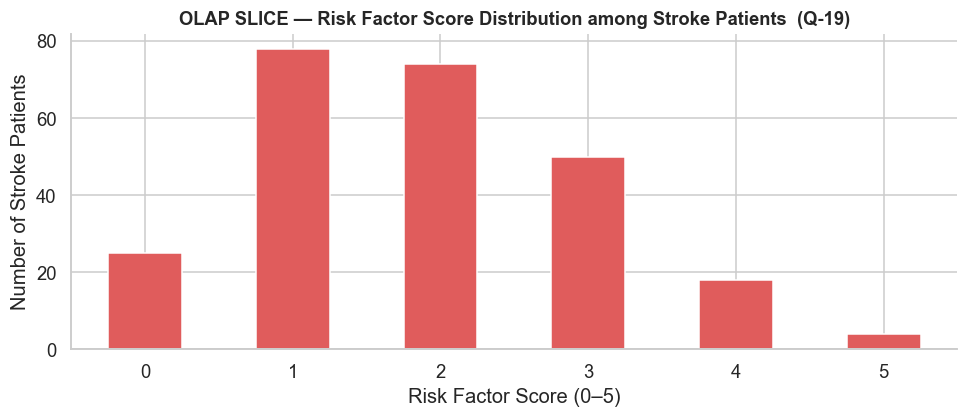

  [SAVED] reports/figures/38_sql_slice_risk_score_distribution.png


In [19]:
# Q-19 : OLAP SLICE — High-Risk Stroke Patient Registry  (label = 1 only)

q19 = sql('''
    SELECT
        dp.patient_id,
        ROUND(dp.age, 0)                             AS age,
        CASE dp.gender WHEN 1 THEN 'Male' ELSE 'Female' END AS gender,
        fs.hypertension,
        fs.heart_disease,
        CASE fs.ever_married WHEN 1 THEN 'Yes' ELSE 'No' END AS ever_married,
        fs.work_type,
        CASE fs.residence_type WHEN 1 THEN 'Urban' ELSE 'Rural' END AS residence,
        ROUND(fs.avg_glucose_level, 1)               AS glucose_mg_dl,
        ROUND(fs.bmi, 1)                             AS bmi,
        fs.smoking_status,
        (  fs.hypertension
         + fs.heart_disease
         + CASE WHEN dp.age >= 65             THEN 1 ELSE 0 END
         + CASE WHEN fs.avg_glucose_level>140 THEN 1 ELSE 0 END
         + CASE WHEN fs.bmi > 30              THEN 1 ELSE 0 END
        )                                            AS risk_factor_score
    FROM  fact_stroke fs
    JOIN  dim_patient dp ON fs.patient_id = dp.patient_id
    WHERE fs.label = 1
    ORDER BY risk_factor_score DESC, dp.age DESC
    LIMIT 20
''', title="Q-19: SLICE — Top 20 Highest-Risk Stroke Patients")

display(q19.style
           .background_gradient(subset=['risk_factor_score'], cmap='Reds')
           .format({'glucose_mg_dl': '{:.1f}', 'bmi': '{:.1f}'}))

# Risk score distribution among stroke patients
q19_all = pd.read_sql_query('''
    SELECT
        (fs.hypertension + fs.heart_disease
         + CASE WHEN dp.age>=65 THEN 1 ELSE 0 END
         + CASE WHEN fs.avg_glucose_level>140 THEN 1 ELSE 0 END
         + CASE WHEN fs.bmi>30 THEN 1 ELSE 0 END) AS risk_factor_score
    FROM fact_stroke fs JOIN dim_patient dp ON fs.patient_id=dp.patient_id
    WHERE fs.label=1
''', conn)

fig, ax = plt.subplots(figsize=(9, 4))
q19_all['risk_factor_score'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color='#E05C5C', edgecolor='white', rot=0)
ax.set_xlabel('Risk Factor Score (0–5)')
ax.set_ylabel('Number of Stroke Patients')
ax.set_title('OLAP SLICE — Risk Factor Score Distribution among Stroke Patients  (Q-19)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
savefig('38_sql_slice_risk_score_distribution.png')

  Q-20: DICE — High-Risk Subgroups Across All 3 Diseases  (3 rows x 5 cols)


,subgroup,patients,avg_age,avg_aq_score,pct_family_history
0,Autism: Older Male ASD Positive,621,29.4,8.21,24.2%
1,Diabetes: Polyuria+Polydipsia Positive,193,49.4,nan,20.7%
2,Stroke: HTN+HeartDisease Positive,13,72.8,nan,38.5%


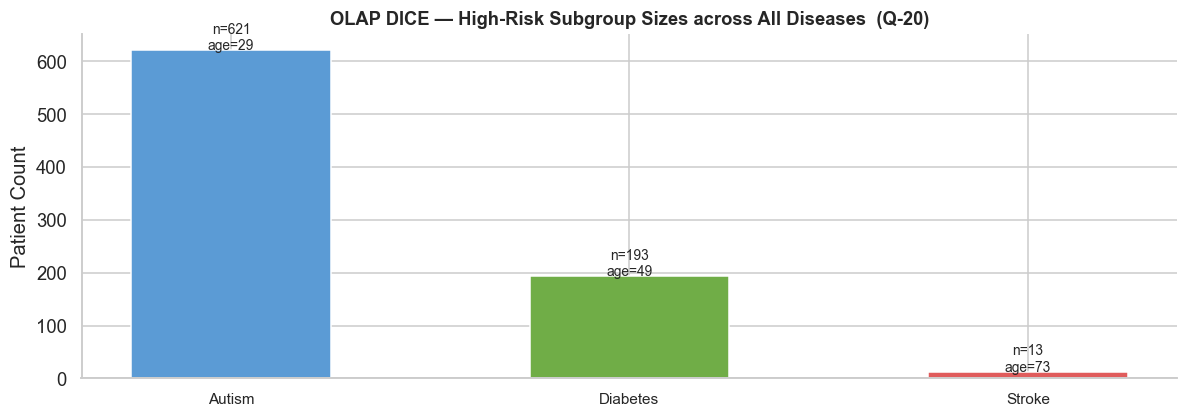

  [SAVED] reports/figures/39_sql_dice_high_risk_subgroups.png


In [20]:
# Q-20 : OLAP DICE — High-Risk Subgroup Identification across All 3 Diseases

q20 = sql('''
    SELECT 'Autism: Older Male ASD Positive' AS subgroup,
           COUNT(*) AS patients,
           ROUND(AVG(dp.age),1) AS avg_age,
           ROUND(AVG(fa.aq_score),2) AS avg_aq_score,
           ROUND(100.0*SUM(fa.family_asd)/COUNT(*),1) AS pct_family_history
    FROM  fact_autism fa JOIN dim_patient dp ON fa.patient_id=dp.patient_id
    WHERE fa.label=1 AND dp.gender=1 AND dp.age>=12
    UNION ALL
    SELECT 'Diabetes: Polyuria+Polydipsia Positive',
           COUNT(*), ROUND(AVG(dp.age),1), NULL,
           ROUND(100.0*SUM(fd.obesity)/COUNT(*),1)
    FROM  fact_diabetes fd JOIN dim_patient dp ON fd.patient_id=dp.patient_id
    WHERE fd.label=1 AND fd.polyuria=1 AND fd.polydipsia=1
    UNION ALL
    SELECT 'Stroke: HTN+HeartDisease Positive',
           COUNT(*), ROUND(AVG(dp.age),1), NULL,
           ROUND(100.0*SUM(
               CASE WHEN fs.smoking_status='smokes' THEN 1 ELSE 0 END
           )/COUNT(*),1)
    FROM  fact_stroke fs JOIN dim_patient dp ON fs.patient_id=dp.patient_id
    WHERE fs.label=1 AND fs.hypertension=1 AND fs.heart_disease=1
''', title="Q-20: DICE — High-Risk Subgroups Across All 3 Diseases")

display(q20.style
           .format({'patients': '{:,}', 'avg_age': '{:.1f}',
                    'avg_aq_score': '{:.2f}',
                    'pct_family_history': '{:.1f}%'})
           .highlight_max(subset=['patients'], color='#ffc7ce'))

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(range(len(q20)), q20['patients'],
              color=['#5B9BD5','#70AD47','#E05C5C'],
              edgecolor='white', width=0.5)
ax.set_xticks(range(len(q20)))
ax.set_xticklabels([s.split(':')[0] for s in q20['subgroup']], fontsize=10)
for bar, (_, row) in zip(bars, q20.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            "n=" + str(int(row['patients'])) + "\nage=" + str(round(row['avg_age'])),
            ha='center', fontsize=9)
ax.set_ylabel('Patient Count')
ax.set_title('OLAP DICE — High-Risk Subgroup Sizes across All Diseases  (Q-20)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
savefig('39_sql_dice_high_risk_subgroups.png')

In [21]:
import glob

conn.close()
print("Database connection closed.")
print()

all_figs = sorted(glob.glob(str(FIGS / '*.png')))
new_figs  = [f for f in all_figs
             if any(os.path.basename(f).startswith(str(n))
                    for n in range(29, 40))]

print("=" * 65)
print("  SQL ANALYSIS NOTEBOOK — COMPLETE")
print("=" * 65)
print(f"  Queries executed    : 20")
print(f"  OLAP operations     : Roll-Up, Drill-Down, Slice, Dice")
print(f"  New figures (SQL)   : {len(new_figs)}")
for f in new_figs:
    kb = os.path.getsize(f) / 1024
    print(f"    {os.path.basename(f):<42}  {kb:>5.1f} KB")
print(f"  Total project figs  : {len(all_figs)}")
print()
print("  SQL files documented:")
print("    warehouse/schema.sql              (DDL + design rationale)")
print("    warehouse/analytical_queries.sql  (20 queries with comments)")
print("    warehouse/03_sql_analysis.ipynb   (interactive notebook)")
print("=" * 65)

Database connection closed.

  SQL ANALYSIS NOTEBOOK — COMPLETE
  Queries executed    : 20
  OLAP operations     : Roll-Up, Drill-Down, Slice, Dice
  New figures (SQL)   : 11
    29_sql_avg_age_per_cohort.png                39.7 KB
    30_sql_age_bracket_rollup.png                92.5 KB
    31_sql_gender_distribution.png               96.8 KB
    32_sql_imbalance_ratio.png                   54.3 KB
    33_sql_positive_vs_negative_age.png          52.6 KB
    34_sql_aq_score_distribution.png             60.7 KB
    35_sql_diabetes_symptom_gap.png             104.4 KB
    36_sql_smoking_stroke_rate.png               51.5 KB
    37_sql_rollup_age_worktype_heatmap.png       89.2 KB
    38_sql_slice_risk_score_distribution.png     44.2 KB
    39_sql_dice_high_risk_subgroups.png          45.9 KB
  Total project figs  : 39

  SQL files documented:
    warehouse/schema.sql              (DDL + design rationale)
    warehouse/analytical_queries.sql  (20 queries with comments)
    warehouse/03_s